In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# The Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score

In [55]:
# Load Data
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [56]:
print(df.shape)
df.info()
df.describe(include='all')

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [57]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [58]:
# Data Cleaning

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

df['tenure'] = df['tenure'].replace(0,1)

df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure']

C:\Users\user\AppData\Local\Temp\ipykernel_30652\2028782370.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)


In [59]:
# churn-rate KPI
churn_rate = df['Churn'].mean()*100
print("Overall Churn Rate:", round(churn_rate,2), "%")

Overall Churn Rate: 26.54 %


C:\Users\user\AppData\Local\Temp\ipykernel_30652\2190081966.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['tenure'], bins=[0,6,12,24,60]))['Churn'].mean().plot(kind='bar')


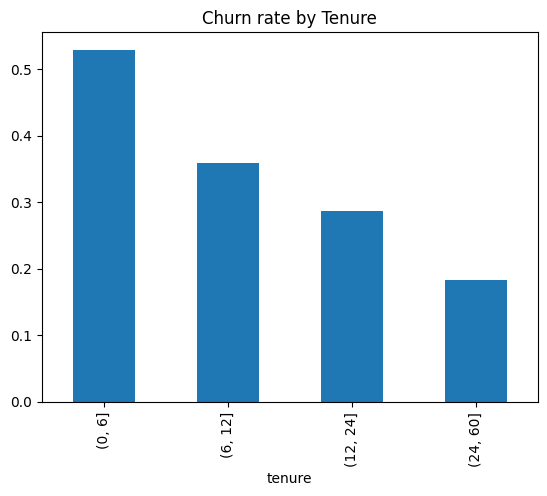

In [60]:
df.groupby(pd.cut(df['tenure'], bins=[0,6,12,24,60]))['Churn'].mean().plot(kind='bar')
plt.title('Churn rate by Tenure')
plt.show()

In [61]:
# Remove ID column

df.drop('customerID', axis=1, inplace=True)

In [62]:
# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

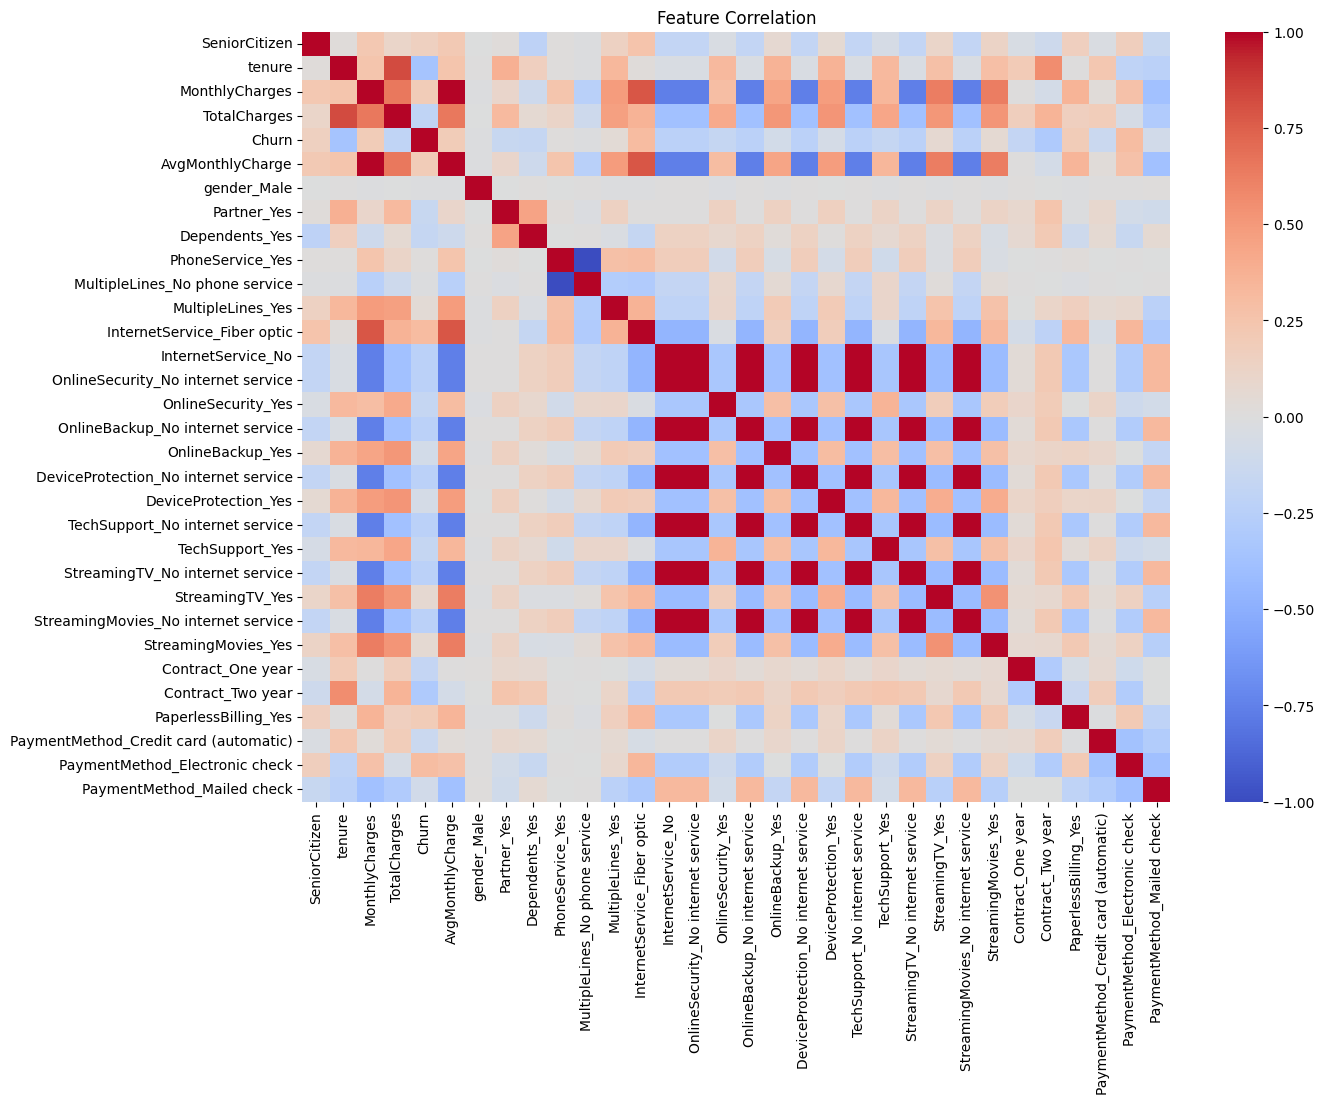

In [63]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [65]:
# Define Features and Target

X = df.drop('Churn', axis=1)
y = df['Churn']

In [66]:
# Define X (Features) and y (Target)

from sklearn.model_selection import train_test_split
# x = df_encoded.drop('Churn', axis=1)
# y = df_encoded['Churn']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training on {x_train.shape[0]} customers. Testing on {x_test.shape[0]} customers.")

Training on 5634 customers. Testing on 1409 customers.


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

lr_model.fit(x_train, y_train)

# Probabilities
lr_prob = lr_model.predict_proba(x_test)[:, 1]

# Threshold tuning for churn recall
lr_pred = (lr_prob > 0.35).astype(int)

print("Logistic Regression Results")
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))


Logistic Regression Results
[[614 421]
 [ 37 337]]
              precision    recall  f1-score   support

           0       0.94      0.59      0.73      1035
           1       0.44      0.90      0.60       374

    accuracy                           0.67      1409
   macro avg       0.69      0.75      0.66      1409
weighted avg       0.81      0.67      0.69      1409

ROC-AUC: 0.8421245705133172


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(x_train, y_train)


rf_prob = rf_model.predict_proba(x_test)[:, 1]
rf_pred = (rf_prob > 0.35).astype(int)

print("\nRandom Forest Results")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))



Random Forest Results
[[836 199]
 [130 244]]
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.55      0.65      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC: 0.8295499754579038


In [75]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

gb_prob = gb_model.predict_proba(x_test)[:, 1]
gb_pred = (gb_prob > 0.35).astype(int)

print("\nGradient Boosting Results")
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_prob))



Gradient Boosting Results
[[821 214]
 [111 263]]
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC: 0.8419088584050222


In [76]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'ROC_AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

model_comparison


,Model,ROC_AUC
0,Logistic Regression,0.842125
1,Random Forest,0.829550
2,Gradient Boosting,0.841909


In [77]:
y_prob = lr_model.predict_proba(x_test)[:,1]
results = x_test.copy()

results['Actual_Churn'] = y_test
results['Churn_Probability'] = y_prob

results['Churn_Risk'] = pd.cut(
    y_prob,
    bins=[0,0.3,0.6,1],
    labels=['Low','Medium','High']
)

results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharge,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Churn_Probability,Churn_Risk
437,0,72,114.05,8468.20,117.613889,True,True,True,True,False,...,True,False,True,True,True,False,False,0,0.117268,Low
2280,1,8,100.15,908.55,113.568750,False,False,False,True,False,...,True,False,False,True,True,False,False,0,0.858321,High
2235,0,41,78.35,3211.20,78.321951,False,True,True,True,False,...,False,True,False,True,True,False,False,0,0.162997,Low
4460,0,18,78.20,1468.75,81.597222,True,True,False,True,False,...,False,False,False,False,False,True,False,0,0.645499,High
3761,0,72,82.65,5919.35,82.213194,False,True,False,True,False,...,True,False,True,True,True,False,False,0,0.056747,Low


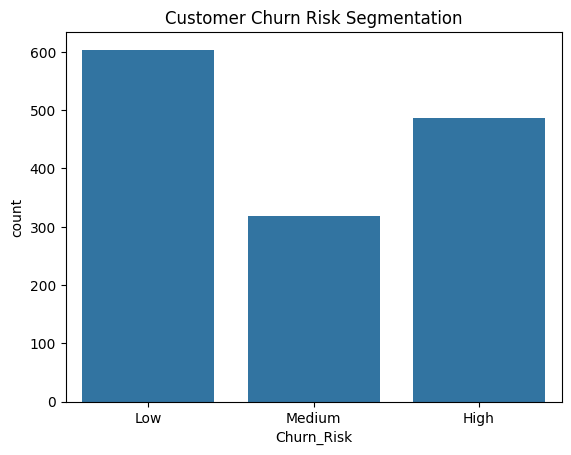

In [78]:

sns.countplot(x='Churn_Risk', data=results)
plt.title("Customer Churn Risk Segmentation")
plt.show()

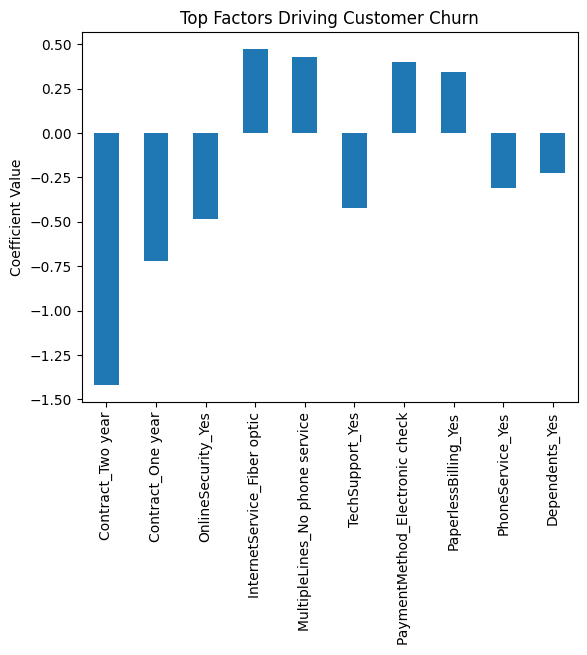

In [84]:
importance = pd.Series(lr_model.coef_[0], index=x_train.columns)

importance.sort_values(key=abs, ascending=False).head(10).plot(kind='bar')

plt.title("Top Factors Driving Customer Churn")
plt.ylabel("Coefficient Value")
plt.show()